# Look at output of climate data aggregation

In [48]:
import os
import rasterio
from rasterio.warp import transform
from rasterio.transform import rowcol
import matplotlib.pyplot as plt
from rasterio.windows import Window
import numpy as np

In [49]:
# TODO: Select desired year and location

# Year
year = 2024 # or leap year 2004

# Desired location (WGS84)
lon = 88.0   # near equator 29.9 # south africa 24 # altai 88.0 # europe 10.0 
lat = 49.0   # near equator -1.8 # south africa -27 # altai 49.0 # europe 50.0

In [50]:
path = "/Volumes/TOSHIBA EXT/non-equilibrium/data/climate_monthly"

# Define months depending on hemisphere
if lat >= 0:
    months = list(range(1, 13))
    years = [year] * 12

else:
    months = list(range(7, 13)) + list(range(1, 7))
    years = [year] * 6 + [year + 1] * 6

print(months)
print(years)

# Create ordered file list
files_vegetation_year = []

for y, m in zip(years, months):
    pattern = os.path.join(
        path,
        f"Climate_monthly_{y}-{m:02d}-01.tif"
    )
    files_vegetation_year.append(pattern)

print(files_vegetation_year)

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
[2024, 2024, 2024, 2024, 2024, 2024, 2024, 2024, 2024, 2024, 2024, 2024]
['/Volumes/TOSHIBA EXT/non-equilibrium/data/climate_monthly/Climate_monthly_2024-01-01.tif', '/Volumes/TOSHIBA EXT/non-equilibrium/data/climate_monthly/Climate_monthly_2024-02-01.tif', '/Volumes/TOSHIBA EXT/non-equilibrium/data/climate_monthly/Climate_monthly_2024-03-01.tif', '/Volumes/TOSHIBA EXT/non-equilibrium/data/climate_monthly/Climate_monthly_2024-04-01.tif', '/Volumes/TOSHIBA EXT/non-equilibrium/data/climate_monthly/Climate_monthly_2024-05-01.tif', '/Volumes/TOSHIBA EXT/non-equilibrium/data/climate_monthly/Climate_monthly_2024-06-01.tif', '/Volumes/TOSHIBA EXT/non-equilibrium/data/climate_monthly/Climate_monthly_2024-07-01.tif', '/Volumes/TOSHIBA EXT/non-equilibrium/data/climate_monthly/Climate_monthly_2024-08-01.tif', '/Volumes/TOSHIBA EXT/non-equilibrium/data/climate_monthly/Climate_monthly_2024-09-01.tif', '/Volumes/TOSHIBA EXT/non-equilibrium/data/climate_monthly

In [51]:
with rasterio.open(files_vegetation_year[0]) as src:

    # Convert lat/lon to raster CRS
    x, y = transform(
        "EPSG:4326",
        src.crs,
        [lon],
        [lat]
    )

    # Convert coordinates to pixel indices
    target_row, target_col = rowcol(
        src.transform,
        x[0],
        y[0]
    )

    # Create valid pixel mask
    band_names = list(src.descriptions)
    tmmn_band = band_names.index("tmmn") + 1

    tmmn = src.read(tmmn_band)
    valid_mask = tmmn != -9999

# Search radius around target pixel
radius = 10

candidates = []

for r in range(
    max(0, target_row - radius),
    min(valid_mask.shape[0], target_row + radius + 1)
):
    for c in range(
        max(0, target_col - radius),
        min(valid_mask.shape[1], target_col + radius + 1)
    ):
        if valid_mask[r, c]:
            distance = (r - target_row)**2 + (c - target_col)**2
            candidates.append((distance, r, c))

# Select nearest valid pixel
_, row, col = min(candidates)

print(f"Selected pixel: row={row}, col={col}")

Selected pixel: row=916, col=5291


/var/folders/v8/1_2rlmrd0wl5w5t5n60h8s440000gn/T/ipykernel_85494/1372104437.py:22: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  tmmn = src.read(tmmn_band)


In [52]:
window_size = 100
half = window_size // 2

row_min = max(0, target_row - half)
row_max = min(valid_mask.shape[0], target_row + half)

col_min = max(0, target_col - half)
col_max = min(valid_mask.shape[1], target_col + half)

print(f"Window: row={row_min}:{row_max}, col={col_min}:{col_max}")

Window: row=866:966, col=5241:5341


In [53]:
window = Window(
    col_off=col_min,
    row_off=row_min,
    width=col_max - col_min,
    height=row_max - row_min
)

In [54]:
def plot_raster_bands(
        raster_file,
        figsize=(14, 10),
        cmap="viridis",
        nodata_value=-9999,
        temperature_bands=None,
        scale_factor=None
):

    with rasterio.open(raster_file) as src:

        data = src.read(window=window).astype("float32")

        # Replace nodata with NaN
        data[data == nodata_value] = np.nan

        # Apply optional scaling
        if scale_factor is not None:
            data *= scale_factor

        band_names = [
            src.descriptions[i]
            if src.descriptions[i] is not None
            else f"Band {i+1}"
            for i in range(src.count)
        ]


    n_bands = data.shape[0]

    ncols = 3
    nrows = int(np.ceil(n_bands / ncols))


    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=figsize
    )

    axes = np.atleast_1d(axes).flatten()


    for i in range(n_bands):

        im = axes[i].imshow(
            data[i],
            cmap=cmap
        )

        axes[i].set_title(
            band_names[i]
        )

        plt.colorbar(
            im,
            ax=axes[i],
            shrink=0.8
        )

        axes[i].axis("off")


    for ax in axes[n_bands:]:
        ax.axis("off")


    plt.tight_layout()
    plt.show()

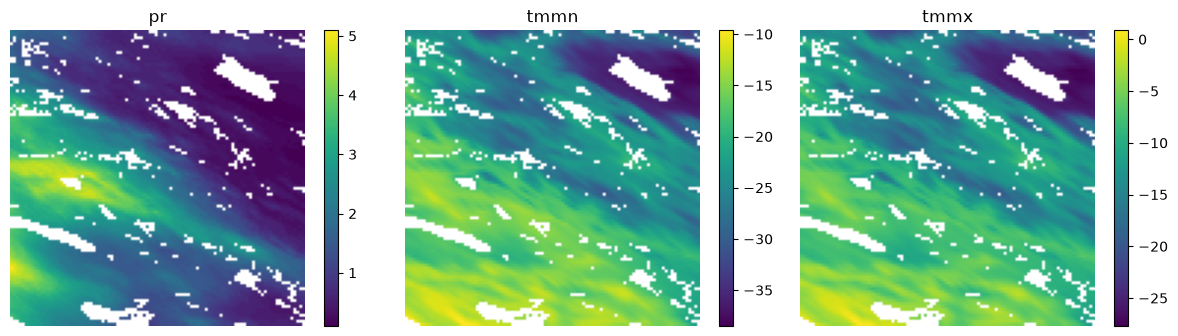

In [55]:
monthly_file = files_vegetation_year[0]

plot_raster_bands(
    monthly_file,
    figsize=(12, 4),
    nodata_value=-9999,
    scale_factor=0.1
)

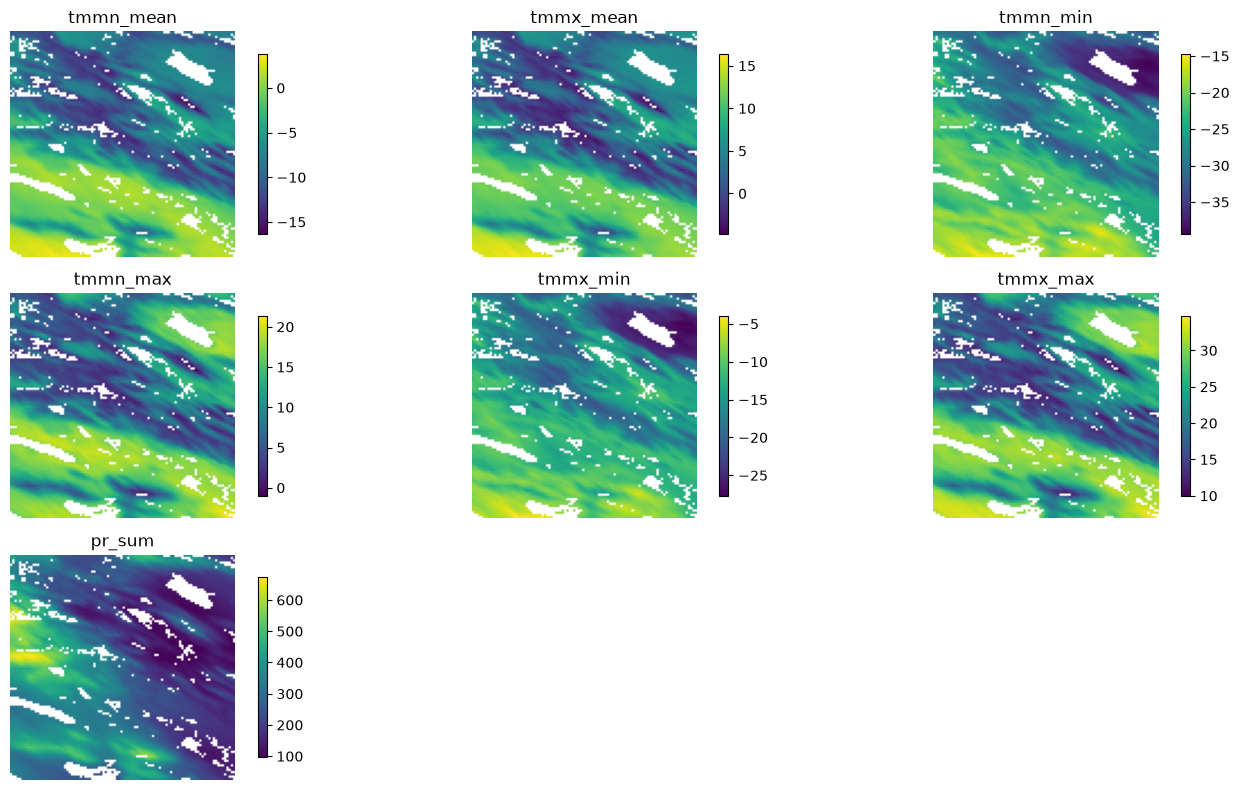

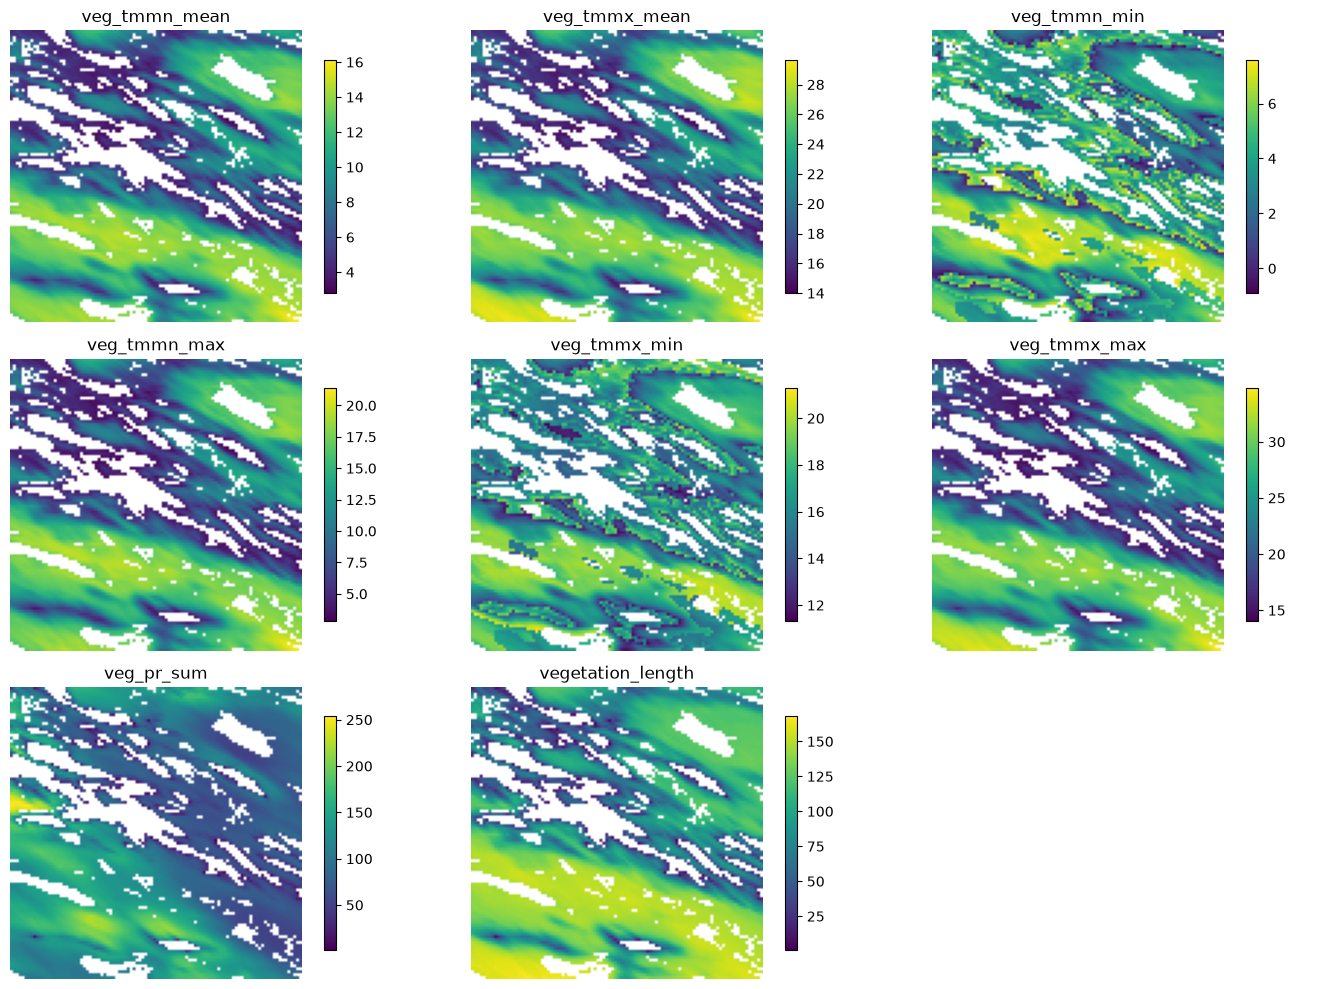

In [56]:
# --------------------------------------------------
# Example usage
# --------------------------------------------------

yearly_file = (
    f'/Volumes/TOSHIBA EXT/non-equilibrium/data/climate_yearly/'
    f"Climate_yearly_{year}.tif"
)

vegetation_file = (
    f'/Volumes/TOSHIBA EXT/non-equilibrium/data/climate_yearly/'
    f"Climate_vegetation_period_{year}.tif"
)

plot_raster_bands(
    yearly_file,
    figsize=(14, 8)
)


plot_raster_bands(
    vegetation_file,
    figsize=(14, 10)
)

In [57]:
with rasterio.open(files_vegetation_year[0]) as src:
    print(src.descriptions)
    print(src.read(1)[0,0])
    print(src.read(2)[0,0])

('pr', 'tmmn', 'tmmx')
-9999
-9999


/var/folders/v8/1_2rlmrd0wl5w5t5n60h8s440000gn/T/ipykernel_85494/1442380739.py:3: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  print(src.read(1)[0,0])
/var/folders/v8/1_2rlmrd0wl5w5t5n60h8s440000gn/T/ipykernel_85494/1442380739.py:4: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  print(src.read(2)[0,0])
